Chapter 24
# Pandas时间序列数据
Book_1《编程不难》 | 鸢尾花书：从加减乘除到机器学习  

## 导入包

In [2]:
# 安装pandas_datareader
! pip install pandas_datareader
# 安装joypy
! pip install joypy
! pip install -U kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.9 MB/s eta 0:00:00


In [1]:
# 导入包
import pandas_datareader as pdr
# 需要安装 pip install pandas_datareader
import joypy
# 需要安装 pip install joypy
import pandas as pd
import datetime
import plotly.express as px
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.options.mode.chained_assignment = None  # default='warn' 关闭链式赋值操作警告。

## 下载数据
从FRED下载标普500 (S&P 500)

In [2]:
# 从FRED下载标普500 (S&P 500)
start_date = datetime.datetime(2014, 1, 1)
end_date   = datetime.datetime(2022, 12, 31)

ticker_list = ['SP500']
df = pdr.DataReader(ticker_list,
                    'fred',
                    start_date,
                    end_date)
# 双备份数据
df.to_csv('SP500_' + str(start_date.date()) + '_'
          + str(end_date.date()) + '.csv')
df.to_pickle('SP500_' + str(start_date.date()) + '_'
             + str(end_date.date()) + '.pkl')
# 从备份数据导入
# df = pd.read_csv('SP500_2014-01-01_2022-12-31.csv',
#                  index_col=0, parse_dates=True) # 将索引为0的列作为行索引
# df = pd.read_pickle('SP500_2014-01-01_2022-12-31.pkl')

In [4]:
df

,SP500
DATE,
2016-07-15,2161.74
2016-07-18,2166.89
2016-07-19,2163.78
2016-07-20,2173.02
2016-07-21,2165.17
...,...
2022-12-26,NaN
2022-12-27,3829.25
2022-12-28,3783.22


In [3]:
df.head()

,SP500
DATE,
2016-07-15,2161.74
2016-07-18,2166.89
2016-07-19,2163.78
2016-07-20,2173.02
2016-07-21,2165.17


In [5]:
df.tail()

,SP500
DATE,
2022-12-26,NaN
2022-12-27,3829.25
2022-12-28,3783.22
2022-12-29,3849.28
2022-12-30,3839.50


In [6]:
len(df)

1686

## 时间序列趋势

In [7]:
# 含有缺失值的时间序列线图

fig = px.line(df)
fig.update_layout(xaxis_title = 'Date',
                  yaxis_title = 'S&P 500 index',
                  legend_title = 'Curve',
                  showlegend=False)
#legend_title = 'Curve'：设置图例（右上角区分不同颜色线条的小框）的标题为“Curve”（曲线）
fig.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




### 缺失值

中%.3f 表示要插入一个浮点数，并保留三位小数。注意，%% 表示要插入一个百分号字
符 %。因为 % 在格式化字符串中具有特殊含义；所以如果要打印百分号字符本身，需要用两个百分号 %% 来表示。

计算缺失值比例。isnull() 方法用于检查 DataFrame 中的每个元素是否为缺失值 NaN。它
返回一个与原始 DataFrame 相同形状的布尔值 DataFrame，其中每个元素都是一个布尔值，表示对
应位置是否是缺失值。True (1) 代表缺失，False (0) 代表存在。方法.sum() 对每列求和，得
到每列中缺失值的总数。len(df) 则计算数据帧的总行数。

In [8]:
# 计算缺失值比例
percentag_missing = df.isnull().sum()*100/len(df)
print('Percentage of missing data')
print("%.3f%%" % (percentag_missing))

Percentage of missing data
3.440%


/tmp/ipykernel_1102/2488042890.py:4: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



参数 cbar=False表示不绘制颜色条 (colorbar)，即颜色映射和数值关系。

df.isnull()计算null值缺失值

利用 seaborn.heatmap() 绘制热图展示缺失值，具体如图 1 (b) 所示。参数 cbar=False
表示不绘制颜色条 (colorbar)，即颜色映射和数值关系。
参数 cmap='YlGnBu'指定了用于渲染热图的颜色映射为'YlGnBu' 颜色映射，它表示黄色到蓝
色的渐变，用于表示缺失值的程度。
参数 yticklabels=[]用于指定 Y 轴上的刻度标签。通过将其设置为空列表 []，我们不显示 Y
轴上的刻度标签。


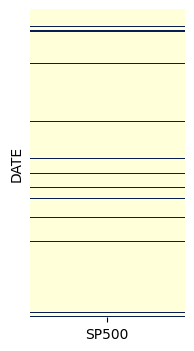

In [9]:
# 可视化缺失值
fig, ax = plt.subplots(figsize = (2,4))

sns.heatmap(df.isnull(), cbar = False, cmap = 'YlGnBu', yticklabels = [])
plt.show()

利用 dropna()方法删除包含缺失值 NaN 的行 (默认)。如果希望删除包含缺失值的
列，可以传递额外的参数 axis=1。

In [10]:
# 删除NaN
df_ = df.dropna()
percentag_missing = df_.isnull().sum()*100/len(df)
# 再次确认缺失值比例
print('Percentage of missing data')
print("%.3f%%" % (percentag_missing))


Percentage of missing data
0.000%


/tmp/ipykernel_1102/3053422828.py:6: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



In [12]:
df_

,SP500
DATE,
2016-07-15,2161.74
2016-07-18,2166.89
2016-07-19,2163.78
2016-07-20,2173.02
2016-07-21,2165.17
...,...
2022-12-23,3844.82
2022-12-27,3829.25
2022-12-28,3783.22


In [14]:
print(type(df_))

<class 'pandas.core.frame.DataFrame'>


In [11]:
# 删除缺失值的时间序列线图
fig = px.line(df_, y = 'SP500', title = 'S&P 500 index')
# y = "SP500"取名为这一列
fig.show()

In [18]:
df_.head()

,SP500,Year
DATE,,
2016-07-15,2161.74,2016
2016-07-18,2166.89,2016
2016-07-19,2163.78,2016
2016-07-20,2173.02,2016
2016-07-21,2165.17,2016


参数facet_col='Year'启用了多列子图。
也就是说，我们根据"Year"列的不同值将数据分成不同的列绘制不同年份数据的子图。
facet_row=None 这个参数表示不启用按行分面绘制，即子图不会按行分割。

利用.year 这个 DatetimeIndex 对象的属性，用于从日期中提取年份信息。它会返回一
个包含与索引中日期时间对应的年份的 Pandas Series。

参数 margin=dict(l=20, r=20, t=30, b=20) 设置图表的边距 (margin)。
dict 函数创建了一个包含左边距 (l)、右边距 (r)、顶部边距 (t)、底部边距 (b) 的字典。
这些值表示图表内容与图表边界之间的像素间隔。例如，l=20 表示左边距为 20 像素。
paper_bgcolor="white"设置图表的背景颜色为白色。


In [15]:
# 按年度分图展示时间序列趋势
df_['Year'] = pd.DatetimeIndex(df_.index).year
fig = px.line(df_, y = 'SP500', title = 'S&P 500 index',
              facet_col='Year', facet_row=None)

fig.update_layout(
    width=700,
    height=500,
    margin=dict(l=20, r=20, t=30, b=20),
    paper_bgcolor="white",
)
fig.update_xaxes(matches=None)
fig.show()

### 趋势

方法.rolling(20) 执行移动计算，例如移动平均。20 表示移动窗口长度，即在计算移动均值
时要考虑的数据点的数量。
方法.mean() 表示对移动窗口内的数据计算均值。
注意，在使用 rolling 方法时，默认 center=False。

当设置 center = False 时，移动窗口的标签将被设置为窗口索引的右边
缘；也就是说，窗口的标签与移动窗口的右边界对齐。这意味着移动窗口中的数据包括右边界，但不包
括左边界。
如图 6 (b) 所示，当 center=True 时，移动窗口的标签将被设置为窗口索引的中心。也就是
说，窗口的标签位于移动窗口的中间。这意味着移动窗口中的数据将包括左右两边的数据，并且标签位
于窗口中央。

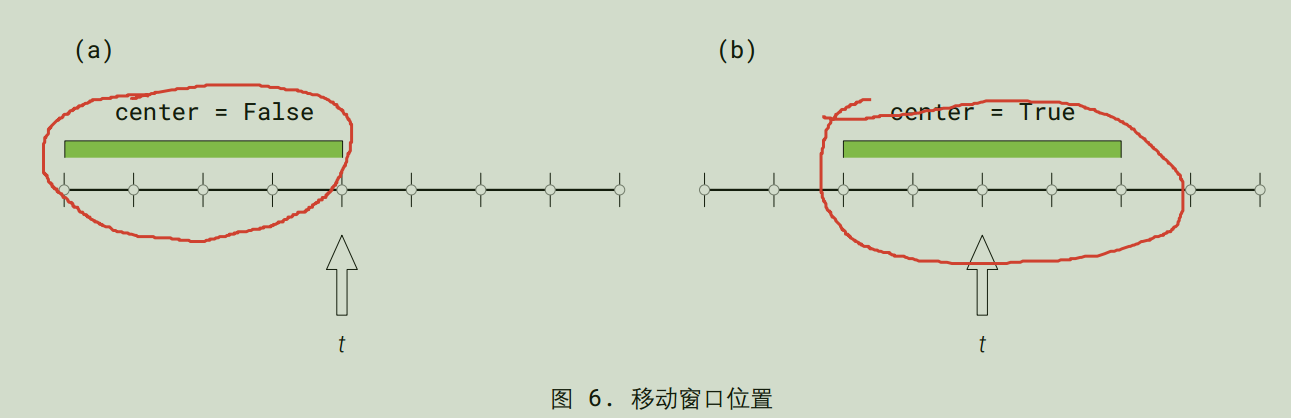

In [19]:
# 计算三种移动平均
df_['MA20'] = df_['SP500'].rolling(20).mean()
df_['MA10'] = df_['SP500'].rolling(10).mean()
df_['MA5'] = df_['SP500'].rolling(5).mean()
# 选取多列
fig = px.line(df_[['SP500','MA20','MA10','MA5']].loc['20210101':'20221231'])
fig.update_layout(title = 'S&P 500 index and moving average',
                  xaxis_title = 'Date',
                  yaxis_title = 'S&P500',
                  legend_title = 'Curve')

fig.show()

In [20]:
# 分年度显示移动平均
fig = px.line(df_,y = ['SP500','MA20'], title = 'S&P 500 index',
              facet_col='Year', facet_row=None)
# ['SP500','MA20']有两条曲线
fig.update_layout(
    width=700,
    height=500,
    margin=dict(l=20, r=20, t=30, b=20),
    paper_bgcolor="white",
)
fig.update_xaxes(matches=None)
fig.show()

## 收益率

### 趋势

In [22]:
df_

,SP500,Year,MA20,MA10,MA5,daily_r
DATE,,,,,,
2016-07-15,2161.74,2016,NaN,NaN,NaN,NaN
2016-07-18,2166.89,2016,NaN,NaN,NaN,0.238234
2016-07-19,2163.78,2016,NaN,NaN,NaN,-0.143524
2016-07-20,2173.02,2016,NaN,NaN,NaN,0.427030
2016-07-21,2165.17,2016,NaN,NaN,2166.120,-0.361248
...,...,...,...,...,...,...
2022-12-23,3844.82,2022,3943.0215,3893.857,3836.986,0.586806
2022-12-27,3829.25,2022,3936.2870,3877.726,3839.304,-0.404960
2022-12-28,3783.22,2022,3927.5665,3854.083,3831.624,-1.202063


.pct_change() 方法用于计算列中相邻两个值相对变化，即日收益率。

日收益率 = (当日收盘价 − 前一日收盘价) / 前一日收
盘价。将这个公式应用于具体的股票数据，就可以计算出每个交易日的日收益率。图 7 所示为标普 500
的日收益率

In [21]:
df_['daily_r'] = df_['SP500'].pct_change() * 100  #百分比
# 计算日收益率
# 小数转为百分数

fig = px.line(df_, y = 'daily_r')
fig.update_layout(title = 'Daily relative return',
                  xaxis_title = 'Date',
                  yaxis_title = 'Daily return (%)',
                  legend_title = 'Curve')

fig.show()


In [23]:
# 日收益率，按年子图
fig = px.line(df_,y = ['daily_r'], title = 'S&P 500 index',
              facet_col='Year', facet_row=None) #同一行

fig.update_layout(
    width=700,
    height=500,
    margin=dict(l=20, r=20, t=30, b=20),
    paper_bgcolor="white",
)
fig.update_xaxes(matches=None)

In [24]:
# 可视化特定时间序列切片
fig = px.line(df_['20200101':'20201231'], y = 'daily_r')
# 取一段时间的数据
fig.update_layout(title = 'Daily relative return',
                  xaxis_title = 'Date',
                  yaxis_title = 'Daily return (%)',
                  legend_title = 'Curve')

fig.show()

### 收益率分布

<Axes: >

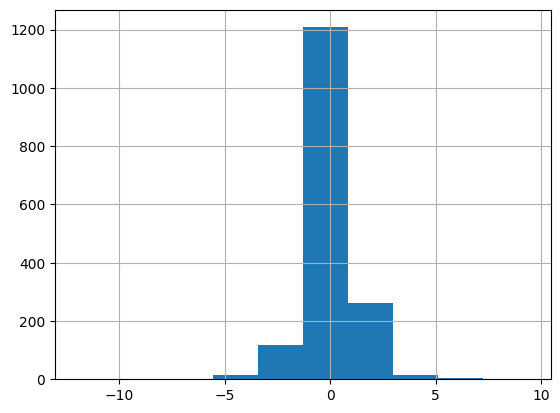

In [25]:
df_['daily_r'].hist()

In [26]:
# 计算均值和标准差
mean = np.mean(df_['daily_r'])
std = np.std(df_['daily_r'])

# 绘制直方图
fig = px.histogram(df_['daily_r'], nbins=50,
                   histnorm='probability density') #概率密度

# 标注均值和均值加减标准差的位置
fig.add_shape(type='line', x0=mean, y0=0, x1=mean, y1=1, #x（mean,0）;y(mean, 1)
              line=dict(color='red', dash='dash'), name='mean')

fig.add_shape(type='line', x0=mean+std, y0=0, x1=mean+std, y1=1,
              line=dict(color='red', dash='dash'), name='mean+std')

fig.add_shape(type='line', x0=mean-std, y0=0, x1=mean-std, y1=1,
              line=dict(color='red', dash='dash'), name='mean-std')

# 设置图形布局
fig.update_layout(showlegend=False,
                  xaxis_title = 'Daily return (%)',
                  yaxis_title = 'Probability density')

# 显示图形
fig.show()

In [27]:
df_.columns

Index(['SP500', 'Year', 'MA20', 'MA10', 'MA5', 'daily_r'], dtype='object')

In [28]:
df_.columns.values
# 将列标签转为了数组 df.index.to_numpy()

array(['SP500', 'Year', 'MA20', 'MA10', 'MA5', 'daily_r'], dtype=object)

In [30]:
print(type(df_.columns.values))

<class 'numpy.ndarray'>


In [29]:
df_.columns.names

FrozenList([None])

其中， a
也是绘制直方图，不同的是我们利用 orientation='h'这个参数设置直方图的方向为
水平方向，即柱子是水平放置的。如果设置 orientation 为 'v'，则柱子将垂直放置，这也是默认
方向。
此外，facet_col='Year'这个参数启用了子图绘制，根据不同年份将数据分成不同的列绘制子
图。
b
也是修改图像默认设置。
c
则是利用.update_xaxes() 方法通过将 matches 参数设置为 'x'，让所有子图横轴的属
性都设置为相同的值，以使它们在图表中具有一致的外观和行为。

In [31]:
# 每年收益率直方图
# 取['daily_r','Year']数据；将year进行子图的依据
fig = px.histogram(df_[['daily_r','Year']], nbins=80,
                   histnorm='probability density',
                   title = 'S&P 500 index',
                   orientation='h',
                   facet_col='Year', facet_row=None)

fig.update_layout(
    width=1200,
    height=500,
    margin=dict(l=20, r=20, t=30, b=20),
    paper_bgcolor="white",
)
fig.update_xaxes(matches='x')
fig.show()


### 每一年均值、标准差 (波动率)

In [32]:
df_['Year'] = pd.DatetimeIndex(df_.index).year
df_

,SP500,Year,MA20,MA10,MA5,daily_r
DATE,,,,,,
2016-07-15,2161.74,2016,NaN,NaN,NaN,NaN
2016-07-18,2166.89,2016,NaN,NaN,NaN,0.238234
2016-07-19,2163.78,2016,NaN,NaN,NaN,-0.143524
2016-07-20,2173.02,2016,NaN,NaN,NaN,0.427030
2016-07-21,2165.17,2016,NaN,NaN,2166.120,-0.361248
...,...,...,...,...,...,...
2022-12-23,3844.82,2022,3943.0215,3893.857,3836.986,0.586806
2022-12-27,3829.25,2022,3936.2870,3877.726,3839.304,-0.404960
2022-12-28,3783.22,2022,3927.5665,3854.083,3831.624,-1.202063


参数 by="Year" 指定了数据帧的一个列，用于将数据按照年份进行分组。也就是说，每个年份对
应山脊图中一个分布。
参数 ax=ax 指定了用于绘制 joyplot 的坐标轴对象。变量 ax 对应上一句用
plt.subplots(figsize = (6,4)) 生成的轴对象 ax。
column="daily_r" 这个参数指定显示每天收益率分布情况。

参数 range_style='own'表示每个年份的分布图会根据数据的范围自动调整，以便更好地显示
数据。


参数 grid="y"表示只显示垂直网格线。

参数 linewidth=1 指定了分布线条的宽度，用于绘制分布图。

参数 legend=False 这个参数表示不显示图例。

参数 fade=True 给山脊图添加渐变效果。
参数 kind="counts"指定了分布图的类型为计数。

参数 bins=100 指定了数据分布图中的直方图区间数。
colormap=cm.autumn_r 指定了用于渲染山脊图的颜色映射为

"autumn_r" 颜色映射，该映射主题为“秋色”，红黄渐变。注意，_r 代表翻转颜色映射；请大家修改
代码尝试"autumn" 颜色映射，并对比效果。

/usr/local/lib/python3.12/dist-packages/joypy/joyplot.py:435: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



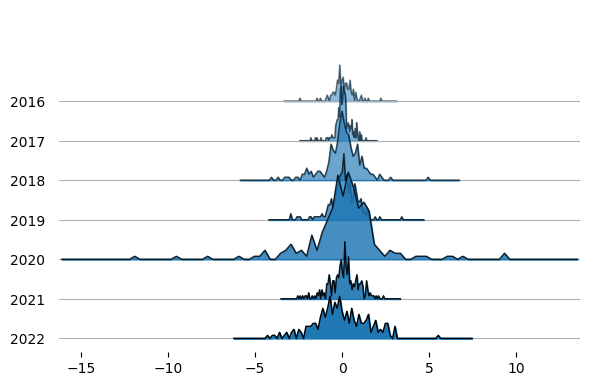

In [35]:
df_['Year'] = pd.DatetimeIndex(df_.index).year #获取年份
# 绘制山脊图

from matplotlib import cm
fig, ax = plt.subplots(figsize = (6,4))
joypy.joyplot(df_, by="Year", ax = ax,
              column="daily_r", range_style='own',
              grid="y", linewidth=1, legend=False,
              fade=True,kind="counts", bins=100)
#kind="counts--计数
plt.show()

/usr/local/lib/python3.12/dist-packages/joypy/joyplot.py:435: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



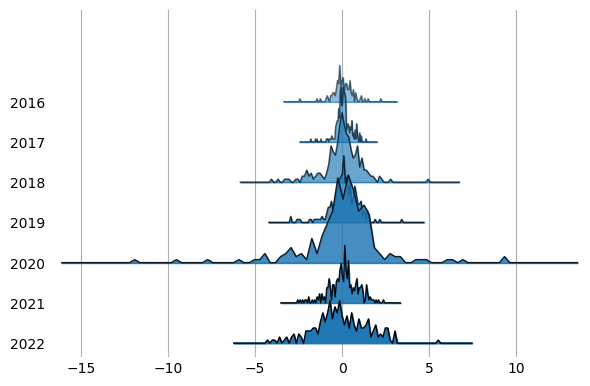

In [36]:
fig, ax = plt.subplots(figsize = (6,4))
joypy.joyplot(df_, by="Year", ax = ax,
              column="daily_r", range_style='own',
              grid="x", linewidth=1, legend=False,
              fade=True,kind="counts", bins=100)
plt.show()

/usr/local/lib/python3.12/dist-packages/joypy/joyplot.py:435: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



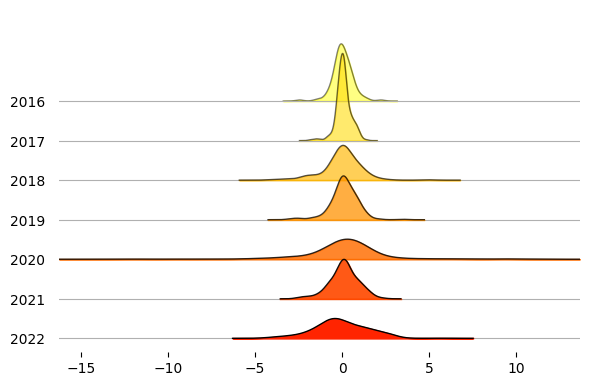

In [37]:
# KDE
fig, ax = plt.subplots(figsize = (6,4))
joypy.joyplot(df_, by="Year", column="daily_r", ax = ax,
              range_style='own', grid="y",
              linewidth=1, legend=False,
              colormap=cm.autumn_r, fade=True)
plt.show()

fig.savefig('Figures\山脊图，KDE.svg', format='svg')

/usr/local/lib/python3.12/dist-packages/joypy/joyplot.py:435: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



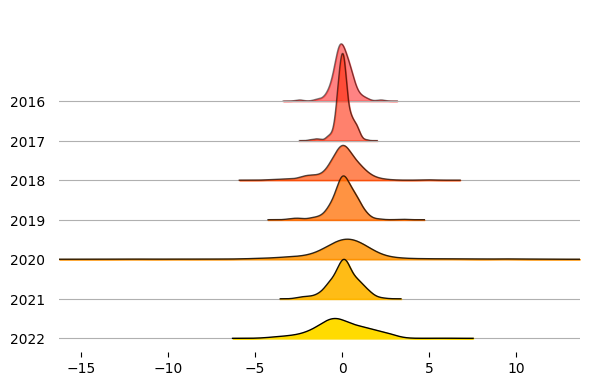

In [38]:
fig, ax = plt.subplots(figsize = (6,4))
joypy.joyplot(df_, by="Year", column="daily_r", ax = ax,
              range_style='own', grid="y",
              linewidth=1, legend=False,
              colormap=cm.autumn, fade=True)
plt.show()

In [40]:
Yearly_stats_df2 = df_.groupby(['Year']).agg({'daily_r':['mean','std']})
Yearly_stats_df2

daily_r          
          mean       std
Year                    
2016  0.031599  0.576153
2017  0.071616  0.421157
2018 -0.019889  1.074153
2019  0.103801  0.785165
2020  0.083217  2.168971
2021  0.097951  0.825132
2022 -0.074544  1.522789

In [42]:
Yearly_stats_df2.columns

MultiIndex([('daily_r', 'mean'),
            ('daily_r',  'std')],
           )

In [39]:
Yearly_stats_df = df_.groupby(['Year'],
                              as_index=False).agg({'daily_r':['mean','std']})
Yearly_stats_df

Year   daily_r          
             mean       std
0  2016  0.031599  0.576153
1  2017  0.071616  0.421157
2  2018 -0.019889  1.074153
3  2019  0.103801  0.785165
4  2020  0.083217  2.168971
5  2021  0.097951  0.825132
6  2022 -0.074544  1.522789

In [41]:
Yearly_stats_df.columns

MultiIndex([(   'Year',     ''),
            ('daily_r', 'mean'),
            ('daily_r',  'std')],
           )

In [44]:
Yearly_stats_df['daily_r']

,mean,std
0,0.031599,0.576153
1,0.071616,0.421157
2,-0.019889,1.074153
3,0.103801,0.785165
4,0.083217,2.168971
5,0.097951,0.825132
6,-0.074544,1.522789


In [43]:
Yearly_stats_df['daily_r']['mean']

,mean
0,0.031599
1,0.071616
2,-0.019889
3,0.103801
4,0.083217
5,0.097951
6,-0.074544


In [45]:
# 使用plotly.express绘制条形图
fig = px.bar(y=Yearly_stats_df['Year'],x=Yearly_stats_df['daily_r']['mean'], title='Mean', orientation='h')

# 因为显示为水平；所以x，y对调

# 设置图形布局
fig.update_layout(showlegend=False,
                  xaxis_title = 'Mean of daily return (%)',
                  yaxis_title = 'Year')
# 显示图形
fig.show()

# pio.write_image(fig, 'Figures/年平均日收益率.svg')

In [46]:
# 使用plotly.express绘制条形图
fig = px.bar(y=Yearly_stats_df['Year'],
             x=Yearly_stats_df['daily_r']['std'],
             title='Daily vol',
             orientation='h')

# 设置图形布局
fig.update_layout(showlegend=False,
                  xaxis_title = 'Volatility of daily return (%)',
                  yaxis_title = 'Year')
# 显示图形
fig.show()
# pio.write_image(fig, 'Figures/年波动率.svg')

### 每一季度均值、标准差 (波动率)

为了更好的量化股票的波动情况，我们需要一个指标——波动率 (volatility)。波动率是衡量其
价格变动幅度的指标，常用的量化方法为历史波动率 (historical volatility)。历史波动率本
质上就是一定回望窗口内收益率样本数据的标准差。


In [48]:
quarters

Index([3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       ...
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4],
      dtype='int32', name='DATE', length=1628)

In [49]:
years

Index([2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016, 2016,
       ...
       2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022, 2022],
      dtype='int32', name='DATE', length=1628)

In [47]:
# 季度均值、标准差

quarters = df_.index.quarter #用.index.quarter 提取季度信息。
years = df_.index.year # 提取年份

# 季度信息
df_['quarter'] = [f"Q{quarter}" for quarter in quarters]

# 将季度和年份信息组合成字符串；使用zip一一对应
quarter_yr = [f"{year}, Q{quarter}" for year, quarter in zip(years, quarters)]

# 添加新列 "Period"
df_['quarter_yr'] = quarter_yr
df_

,SP500,Year,MA20,MA10,MA5,daily_r,quarter,quarter_yr
DATE,,,,,,,,
2016-07-15,2161.74,2016,NaN,NaN,NaN,NaN,Q3,"2016, Q3"
2016-07-18,2166.89,2016,NaN,NaN,NaN,0.238234,Q3,"2016, Q3"
2016-07-19,2163.78,2016,NaN,NaN,NaN,-0.143524,Q3,"2016, Q3"
2016-07-20,2173.02,2016,NaN,NaN,NaN,0.427030,Q3,"2016, Q3"
2016-07-21,2165.17,2016,NaN,NaN,2166.120,-0.361248,Q3,"2016, Q3"
...,...,...,...,...,...,...,...,...
2022-12-23,3844.82,2022,3943.0215,3893.857,3836.986,0.586806,Q4,"2022, Q4"
2022-12-27,3829.25,2022,3936.2870,3877.726,3839.304,-0.404960,Q4,"2022, Q4"
2022-12-28,3783.22,2022,3927.5665,3854.083,3831.624,-1.202063,Q4,"2022, Q4"


In [50]:
type(quarter_yr)

list



1.   by="quarter_yr"按照"quarter_yr"分组
2.   column="daily_r"：数组来源
3.  range_style='own',自动调整范围
4.   kind="counts"计数
5. ax = ax,作用对象

fade=True：

渐变色（非常重要）。让小山包的颜色从顶部的深色渐变到底部的浅色。这不仅是美观，还可以让你一眼看出哪个季度在下层、哪个在上层，不会因为重叠而看不清。


C:\Users\james\anaconda3\lib\site-packages\joypy\joyplot.py:435: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



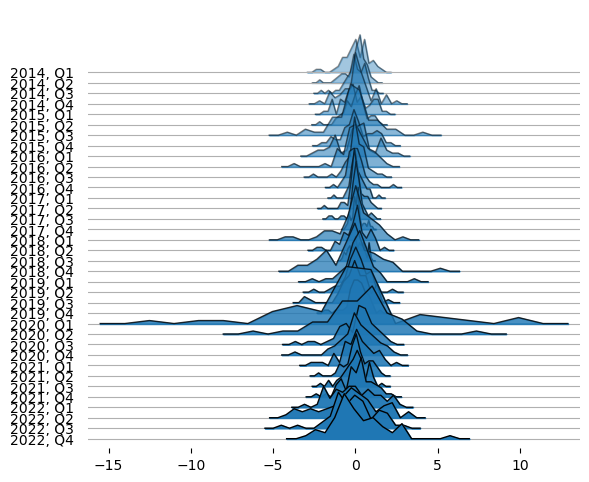

In [ ]:
fig, ax = plt.subplots(figsize = (6,5))

joypy.joyplot(df_, by="quarter_yr", ax = ax,
              column="daily_r", range_style='own',
              grid="y", linewidth=1, legend=False,
              fade=True,kind="counts", bins=20)
plt.show()

/usr/local/lib/python3.12/dist-packages/joypy/joyplot.py:435: UserWarning:

To output multiple subplots, the figure containing the passed axes is being cleared.



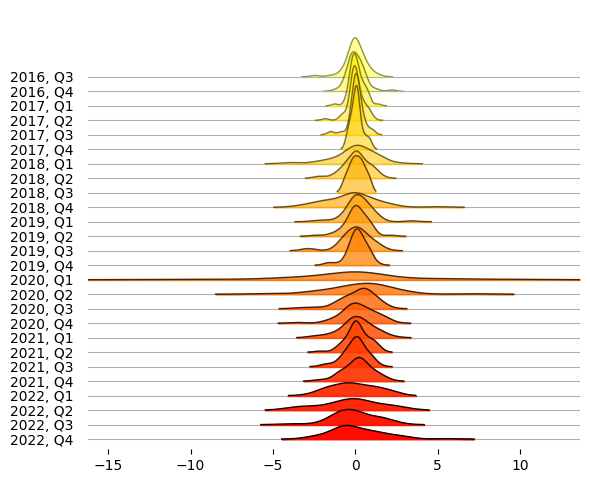

In [51]:
# KDE
fig, ax = plt.subplots(figsize = (6,5))
joypy.joyplot(df_, by="quarter_yr", column="daily_r", ax = ax,
              range_style='own', grid="y",
              linewidth=1, legend=False,
              colormap=cm.autumn_r, fade=True)
plt.show()

In [52]:
Qly_stats_df = df_.groupby(['quarter_yr'], as_index=False).agg({'daily_r':['mean','std']})
#根据quarter_r计算daily_r的均值与标准差
Qly_stats_df

quarter_yr   daily_r          
                   mean       std
0    2016, Q3  0.007471  0.618517
1    2016, Q4  0.052281  0.541388
2    2017, Q1  0.087784  0.422136
3    2017, Q2  0.041323  0.463237
4    2017, Q3  0.062643  0.448068
5    2017, Q4  0.094972  0.350295
6    2018, Q1 -0.012441  1.250448
7    2018, Q2  0.048253  0.786124
8    2018, Q3  0.111371  0.453949
9    2018, Q4 -0.227584  1.496342
10   2019, Q1  0.205112  0.855788
11   2019, Q2  0.061612  0.723675
12   2019, Q3  0.022797  0.934450
13   2019, Q4  0.129773  0.592447
14   2020, Q1 -0.295294  3.587505
15   2020, Q2  0.309015  2.007507
16   2020, Q3  0.132788  1.065023
17   2020, Q4  0.178059  1.025733
18   2021, Q1  0.096965  0.999558
19   2021, Q2  0.127174  0.702674
20   2021, Q3  0.006089  0.703651
21   2021, Q4  0.161988  0.875438
22   2022, Q1 -0.072785  1.353220
23   2022, Q2 -0.273605  1.784536
24   2022, Q3 -0.075709  1.347171
25   2022, Q4  0.120809  1.578901

In [55]:
# 使用plotly.express绘制条形图
fig = px.bar(y=Qly_stats_df['quarter_yr'],
             x=Qly_stats_df['daily_r']['mean'],
             title='Mean',
             orientation='h')

# 设置图形布局
fig.update_layout(showlegend=False,
                  width = 600,
                  height = 800,
                  xaxis_title = 'Mean of daily return (%)',
                  yaxis_title = 'Quarter')
# 显示图形
fig.show()


In [56]:
# 使用plotly.express绘制条形图
fig = px.bar(y=Qly_stats_df['quarter_yr'],
             x=Qly_stats_df['daily_r']['std'],
             title='Volatility',
             orientation='h')

# 设置图形布局
fig.update_layout(showlegend=False,
                  width = 600,
                  height = 800,
                  xaxis_title = 'Vol of daily return (%)',
                  yaxis_title = 'Quarter')
# 显示图形
fig.show()
# pio.write_image(fig, 'Figures/季度波动率.svg')

### 滚动波动率

准确来说，历史波动率是根据过去一段时间内的股票价格数据计算得出的波动率。
可以选择一个时间窗口，例如 20 营业日 (一个月)、60 营业日 (一个季度)、125 或 126 营业日
(半年)、250 或 252 营业日 (一年)，计算每个交易日的收益率，然后求得其标准差，最终得到历史
波动率。
类似移动平均值，当这个回望窗口移动时，我们便得到移动波动率的时间序列数据。
图 15 所示的移动波动率的回望窗口长度为 250 天营业日。请大家自己修改回望窗口长度 (营业日
数量)，比较移动波动率曲线。


In [57]:
df_vol = df_['daily_r'].rolling(250).std()
#根据窗口；计算标准差; 并没有增加新列；而是一个类似series或者数据帧
fig = px.line(df_vol, y = 'daily_r')
fig.update_layout(title = 'Rolling vol',
                  xaxis_title = 'Date',
                  yaxis_title = 'Volatility')

fig.show()


In [58]:
df_vol

,daily_r
DATE,
2016-07-15,NaN
2016-07-18,NaN
2016-07-19,NaN
2016-07-20,NaN
2016-07-21,NaN
...,...
2022-12-23,1.519783
2022-12-27,1.519863
2022-12-28,1.521462


In [59]:
print(type(df_vol))

<class 'pandas.core.series.Series'>


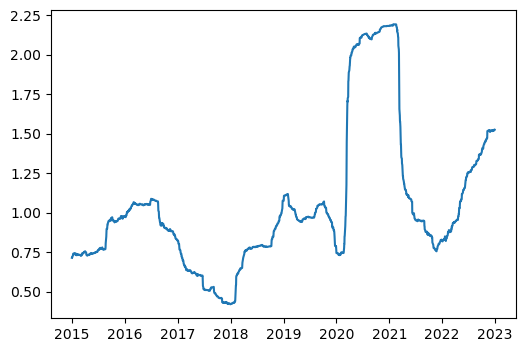

In [ ]:
fig, ax = plt.subplots(figsize = (6,4))

plt.plot(df_vol)
plt.show()


## 相关性系数

### 整体相关性系数

几个不同时间序列之间肯定也会存在相关性。图 16 所示为标普 500 日收益率和三个汇率收益率之
间的相关性系数矩阵热图。注意，这个矩阵是给定历史时间序列数据的“静态”相关性系数。

In [60]:
# 下载更多数据
ticker_list = ['DEXJPUS','DEXCAUS','DEXCHUS','SP500']
df_FX_SP500 = pdr.DataReader(ticker_list,
                    'fred',
                    start_date,
                    end_date)

# 备份数据
df_FX_SP500.to_csv('FX_SP500_' + str(start_date.date()) + '_'
                   + str(end_date.date()) + '.csv')
df_FX_SP500.to_pickle('FX_SP500_' + str(start_date.date()) + '_'
                      + str(end_date.date()) + '.pkl')


In [61]:
# 修改column names
df_FX_SP500 = df_FX_SP500.rename(columns={'DEXJPUS': 'JPY to USD',
                                          'DEXCAUS': 'CAD to USD',
                                          'DEXCHUS':'CNY to USD'})
df_FX_SP500_return = df_FX_SP500.dropna().pct_change()
#先删除 NaN，再计算收益率，即相对涨跌。计算日收益率
df_FX_SP500_return


,JPY to USD,CAD to USD,CNY to USD,SP500
DATE,,,,
2016-07-15,NaN,NaN,NaN,NaN
2016-07-18,0.003408,0.000462,0.002213,0.002382
2016-07-19,0.001226,0.003312,-0.001224,-0.001435
2016-07-20,0.004900,0.000768,-0.002555,0.004270
2016-07-21,-0.006282,0.001457,-0.000374,-0.003612
...,...,...,...,...
2022-12-23,0.003325,-0.004834,0.000730,0.005868
2022-12-27,0.004895,-0.006109,-0.004007,-0.004050
2022-12-28,0.006295,0.006220,0.002500,-0.012021


用 plotly.express.imshow() 绘制相关性矩阵热图。方法 corr() 计算数据帧各列之间
的相关性矩阵。text_auto='.2f'控制在热图上显示的文本标签的格式。.2f 表示将浮点数格式化
为包含两位小数。color_continuous_scale='RdYlBu_r'指定了用于着色的颜色映射。

In [62]:
fig = px.imshow(df_FX_SP500_return.corr(), #相关性系数 4*4
                text_auto = '.2f',
                color_continuous_scale = 'RdYlBu_r')
fig.show()
# pio.write_image(fig, 'Figures/相关性热图.svg')

In [63]:
fig = px.scatter(df_FX_SP500_return, x = 'SP500', y = 'CAD to USD',
                 trendline = 'ols')

# 散点图x = 'SP500', y = 'CAD to USD'
fig.show()

# pio.write_image(fig, 'Figures/散点图，回归线.svg')

### 滚动相关性系数

相关性并不是一成不变的，也是随时间不断变化。如图 17 所示，当我们指定具体的移动窗口长
度，在不同的时间点上都可以计算得到相关性系数。因此，我们也可以得到移动相关性时间序列，这组
数据就变成了“动态”数据。

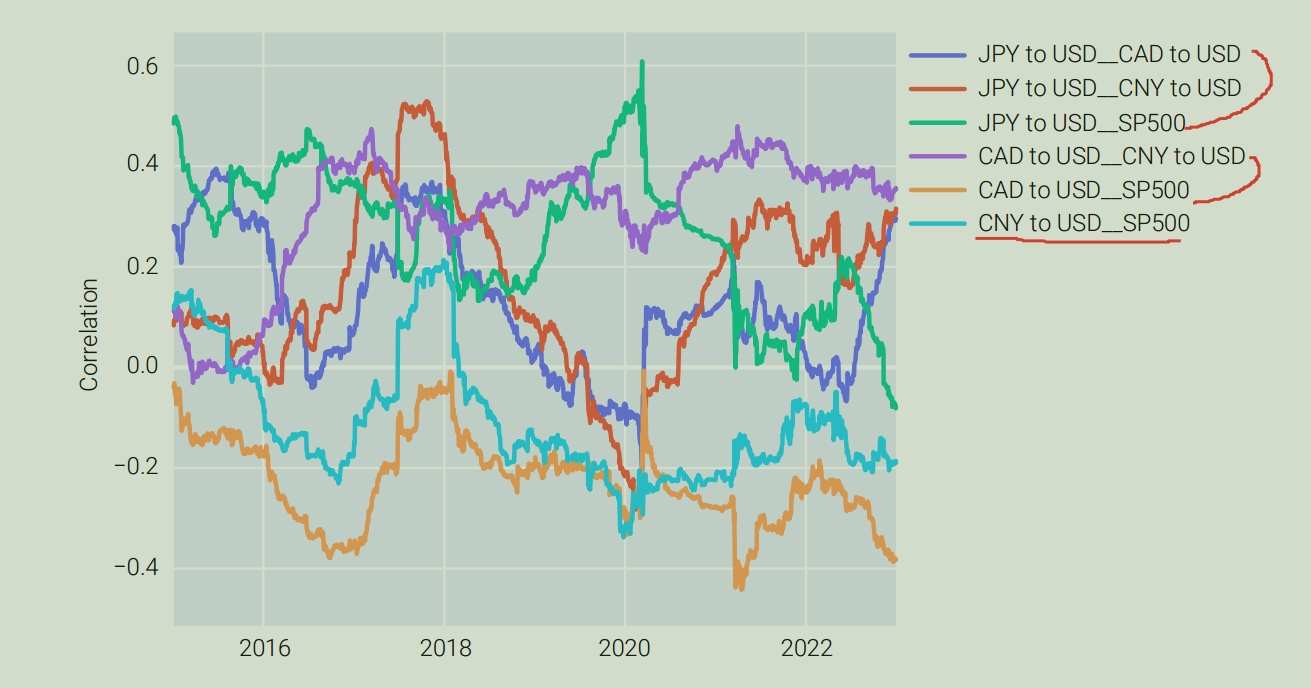

In [64]:
# 计算滚动相关性系数
df_rolling_corr = df_FX_SP500_return.rolling(250).corr().dropna()
# 删除缺失值;corr()将列复制为行索引 4*4
df_rolling_corr

JPY to USD  CAD to USD  CNY to USD     SP500
DATE                                                               
2017-07-18 JPY to USD    1.000000    0.353552    0.518407  0.172282
           CAD to USD    0.353552    1.000000    0.312806 -0.133827
           CNY to USD    0.518407    0.312806    1.000000  0.074227
           SP500         0.172282   -0.133827    0.074227  1.000000
2017-07-19 JPY to USD    1.000000    0.353302    0.517285  0.170668
...                           ...         ...         ...       ...
2022-12-29 SP500        -0.090183   -0.394909   -0.200354  1.000000
2022-12-30 JPY to USD    1.000000    0.291438    0.311166 -0.089333
           CAD to USD    0.291438    1.000000    0.350177 -0.394697
           CNY to USD    0.311166    0.350177    1.000000 -0.196284
           SP500        -0.089333   -0.394697   -0.196284  1.000000

[5424 rows x 4 columns]

In [66]:
df_rolling_corr.index

MultiIndex([('2017-07-18', 'JPY to USD'),
            ('2017-07-18', 'CAD to USD'),
            ('2017-07-18', 'CNY to USD'),
            ('2017-07-18',      'SP500'),
            ('2017-07-19', 'JPY to USD'),
            ('2017-07-19', 'CAD to USD'),
            ('2017-07-19', 'CNY to USD'),
            ('2017-07-19',      'SP500'),
            ('2017-07-20', 'JPY to USD'),
            ('2017-07-20', 'CAD to USD'),
            ...
            ('2022-12-28', 'CNY to USD'),
            ('2022-12-28',      'SP500'),
            ('2022-12-29', 'JPY to USD'),
            ('2022-12-29', 'CAD to USD'),
            ('2022-12-29', 'CNY to USD'),
            ('2022-12-29',      'SP500'),
            ('2022-12-30', 'JPY to USD'),
            ('2022-12-30', 'CAD to USD'),
            ('2022-12-30', 'CNY to USD'),
            ('2022-12-30',      'SP500')],
           names=['DATE', None], length=5424)

In [67]:
df_rolling_corr.columns

Index(['JPY to USD', 'CAD to USD', 'CNY to USD', 'SP500'], dtype='object')

In [65]:
df_rolling_corr.to_csv('df_rolling_corr.csv')

In [69]:
df_rolling_corr.unstack().head(3) #将内层的行索引；转为列索引；成为多级列索引

JPY to USD                                 CAD to USD             \
           CAD to USD CNY to USD JPY to USD     SP500 CAD to USD CNY to USD   
DATE                                                                          
2017-07-18   0.353552   0.518407        1.0  0.172282        1.0   0.312806   
2017-07-19   0.353302   0.517285        1.0  0.170668        1.0   0.309624   
2017-07-20   0.353277   0.517681        1.0  0.171023        1.0   0.312047   

                                CNY to USD                                  \
           JPY to USD     SP500 CAD to USD CNY to USD JPY to USD     SP500   
DATE                                                                         
2017-07-18   0.353552 -0.133827   0.312806        1.0   0.518407  0.074227   
2017-07-19   0.353302 -0.138210   0.309624        1.0   0.517285  0.074340   
2017-07-20   0.353277 -0.137230   0.312047        1.0   0.517681  0.073059   

                SP500                              
           CAD to USD CNY to USD JPY to USD SP500  
DATE                                               
2017-07-18  -0.133827   0.074227   0.172282   1.0  
2017-07-19  -0.138210   0.074340   0.170668   1.0  
2017-07-20  -0.137230   0.073059   0.171023   1.0

In [71]:
df_rolling_corr.unstack().columns

MultiIndex([('JPY to USD', 'CAD to USD'),
            ('JPY to USD', 'CNY to USD'),
            ('JPY to USD', 'JPY to USD'),
            ('JPY to USD',      'SP500'),
            ('CAD to USD', 'CAD to USD'),
            ('CAD to USD', 'CNY to USD'),
            ('CAD to USD', 'JPY to USD'),
            ('CAD to USD',      'SP500'),
            ('CNY to USD', 'CAD to USD'),
            ('CNY to USD', 'CNY to USD'),
            ('CNY to USD', 'JPY to USD'),
            ('CNY to USD',      'SP500'),
            (     'SP500', 'CAD to USD'),
            (     'SP500', 'CNY to USD'),
            (     'SP500', 'JPY to USD'),
            (     'SP500',      'SP500')],
           )

In [70]:
df_rolling_corr.unstack().columns.values #将索引转为numpy数组

array([('JPY to USD', 'CAD to USD'), ('JPY to USD', 'CNY to USD'),
       ('JPY to USD', 'JPY to USD'), ('JPY to USD', 'SP500'),
       ('CAD to USD', 'CAD to USD'), ('CAD to USD', 'CNY to USD'),
       ('CAD to USD', 'JPY to USD'), ('CAD to USD', 'SP500'),
       ('CNY to USD', 'CAD to USD'), ('CNY to USD', 'CNY to USD'),
       ('CNY to USD', 'JPY to USD'), ('CNY to USD', 'SP500'),
       ('SP500', 'CAD to USD'), ('SP500', 'CNY to USD'),
       ('SP500', 'JPY to USD'), ('SP500', 'SP500')], dtype=object)

In [72]:
df_rolling_corr_ = df_rolling_corr.unstack()
df_rolling_corr_.to_csv('wide.csv')

In [73]:
df_rolling_corr_.columns = ['_'.join(col)
                            for col in
                            df_rolling_corr.unstack().columns.values]
# 取出数组中的元素元组如：('SP500', 'CNY to USD') --》SP500_CNY to USD

In [ ]:
# df_rolling_corr.unstack().columns.values

In [74]:
df_rolling_corr_.columns = ['_'.join(col).strip()
                            for col in df_rolling_corr.unstack().columns.values]
# df_rolling_corr_

In [75]:
df_rolling_corr_ = df_rolling_corr_.dropna() #删除缺失值
# df_rolling_corr_

本书第 7 章介绍过如何使用 itertools.combinations()，请大家回顾。
f
用 list()将 DataFrame 列标签转换为一个 Python 列表。
g
类似
c
，用列表生成式和给定的列标签列表 list_tickers 中的所有可能的两两组合 (不考
虑顺序) 连接成一个长度为 6 元素字符串列表 pairs_kept。这个字符串列表代表要保留的相关性系
数曲线。
也就是说，图 16 所示的相关性系数矩阵中，其实我们只关心其中 6 (
2 C4
) 个值。这 6 个值可以是
(不含对角线) 的下三角元素，或者 (不含对角线) 的上三角元素。
h
选定数据帧中要保留的 6 列。
i
用 plotly.express.line() 绘制 6 条移动相关性系数。

In [76]:
df_FX_SP500_return.columns

Index(['JPY to USD', 'CAD to USD', 'CNY to USD', 'SP500'], dtype='object')

combinations(list_tickers,2)
将 list_tickers ['JPY to USD', 'CAD to USD', 'CNY to USD', 'SP500']

取2个数据一共6个 也就是 $C_4^2$ = 6

In [77]:
from itertools import combinations
list_tickers = list(df_FX_SP500_return.columns) # 将其转为列表

pairs_kept = ['_'.join(combo)
              for combo in combinations(list_tickers,2)]
df_rolling_corr_ = df_rolling_corr_[pairs_kept]
# 从原始数据取出我们需要的6列数据
df_rolling_corr_

,JPY to USD_CAD to USD,JPY to USD_CNY to USD,JPY to USD_SP500,CAD to USD_CNY to USD,CAD to USD_SP500,CNY to USD_SP500
DATE,,,,,,
2017-07-18,0.353552,0.518407,0.172282,0.312806,-0.133827,0.074227
2017-07-19,0.353302,0.517285,0.170668,0.309624,-0.138210,0.074340
2017-07-20,0.353277,0.517681,0.171023,0.312047,-0.137230,0.073059
2017-07-21,0.354149,0.521167,0.169674,0.312154,-0.137423,0.077075
2017-07-24,0.356229,0.519834,0.167230,0.313518,-0.135933,0.077916
...,...,...,...,...,...,...
2022-12-23,0.289411,0.302548,-0.080969,0.345684,-0.394367,-0.198021
2022-12-27,0.286208,0.299009,-0.081676,0.349625,-0.391364,-0.196280
2022-12-28,0.288933,0.300350,-0.085278,0.351154,-0.393213,-0.197793


In [78]:
fig = px.line(df_rolling_corr_)
# 每一列就是一条曲线
fig.update_layout(xaxis_title = 'Date',
                  yaxis_title = 'corr',
                  legend_title = 'Pair')

fig.show()

# pio.write_image(fig, 'Figures/滚动相关性系数.svg')

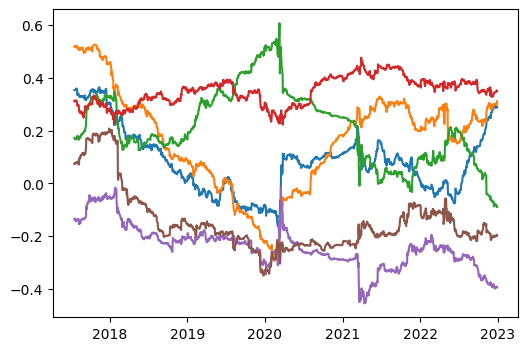

In [79]:
fig, ax = plt.subplots(figsize = (6,4))

plt.plot(df_rolling_corr_)
plt.show()

# fig.savefig('Figures\滚动相关性系数.svg', format='svg')

#回望窗口宽度125

In [80]:
# 计算滚动相关性系数
df_roll_corr = df_FX_SP500_return.rolling(125).corr().dropna()
# 整理数据
df_roll_corr_ = df_roll_corr.unstack()
df_roll_corr_.columns = ['_'.join(col)
 for col in
 df_roll_corr.unstack().columns.values]
df_roll_corr_ = df_roll_corr_.dropna()
# 保留成对相关性数据
#from itertools import combinations
list_tickers = list(df_FX_SP500_return.columns)
pairs_kept = ['_'.join(combo)
 for combo in combinations(list_tickers,2)]
df_roll_corr_ = df_roll_corr_[pairs_kept]
# 可视化
fig = px.line(df_roll_corr_)
fig.update_layout(xaxis_title = 'Date',
 yaxis_title = 'corr',
 legend_title = 'Pair')
fig.show()


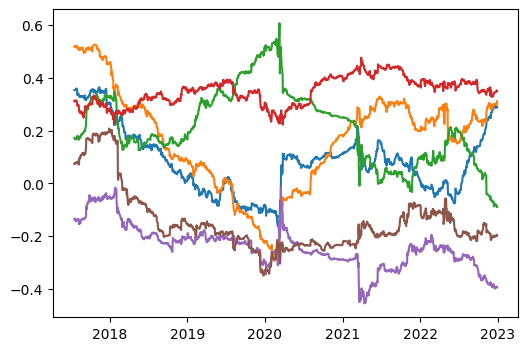

In [81]:
fig, ax = plt.subplots(figsize = (6,4))

plt.plot(df_rolling_corr_)
plt.show()

#回望窗口宽度500

In [82]:
# 计算滚动相关性系数
df_roll_corr = df_FX_SP500_return.rolling(500).corr().dropna()
# 整理数据
df_roll_corr_ = df_roll_corr.unstack()
df_roll_corr_.columns = ['_'.join(col)
 for col in
 df_roll_corr.unstack().columns.values]
df_roll_corr_ = df_roll_corr_.dropna()
# 保留成对相关性数据
#from itertools import combinations
list_tickers = list(df_FX_SP500_return.columns)
pairs_kept = ['_'.join(combo)
 for combo in combinations(list_tickers,2)]
df_roll_corr_ = df_roll_corr_[pairs_kept]
# 可视化
fig = px.line(df_roll_corr_)
fig.update_layout(xaxis_title = 'Date',
 yaxis_title = 'corr',
 legend_title = 'Pair')
fig.show()


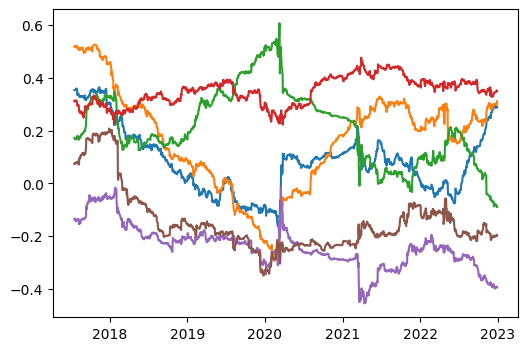

In [83]:
fig, ax = plt.subplots(figsize = (6,4))

plt.plot(df_rolling_corr_)
plt.show()

##好像窗口大小越大；曲线越平滑

In [84]:
# 计算滚动相关性系数
df_roll_corr = df_FX_SP500_return.rolling(800).corr().dropna()
# 整理数据
df_roll_corr_ = df_roll_corr.unstack()
df_roll_corr_.columns = ['_'.join(col)
 for col in
 df_roll_corr.unstack().columns.values]
df_roll_corr_ = df_roll_corr_.dropna()
# 保留成对相关性数据
#from itertools import combinations
list_tickers = list(df_FX_SP500_return.columns)
pairs_kept = ['_'.join(combo)
 for combo in combinations(list_tickers,2)]
df_roll_corr_ = df_roll_corr_[pairs_kept]
# 可视化
fig = px.line(df_roll_corr_)
fig.update_layout(xaxis_title = 'Date',
 yaxis_title = 'corr',
 legend_title = 'Pair')
fig.show()

In [ ]:
# Repo: https://github.com/Visualize-ML
# Book 1 Python for Beginners  |  From Basic Arithmetic to Machine Learning
# Published and copyrighted by Tsinghua University Press
# Beijing, China, 2023